# **Air Quality Monitor Representativeness in the Contiguous United States**

#### **Objective:** Determine whether state and local governments site air monitors in areas that capture data that are representative of actual air quality. For this analysis, compare whether the county's daily median alternative PM2.5 is signficantly less than the daily median alternative PM2.5 value at the PM2.5 air monitor.

#### **Scope:** U.S. PM2.5 air quality monitors in the contiguous U.S. in 2019.

#### **Sources:**

| Num. | Title | Description | Source Link |
| :--- | :------------------------------ | :-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1. | _alternative_PM25_data_w_county_ID_processed_v04.csv_ | This processed dataset contains each PM2.5 monitor location and their alternative PM2.5 estimates for every day in the year 2019 within the contiguous United States. This processed dataset also contains county codes for matching to the county median dataset | NA <br><br> (Developed by this project in E_air_monitors_w_alt_data_and_county_ID) 
| 2. | _county_daily_median_processed_v03.csv_ | This processed dataset contains each contiguous U.S. county and its daily median alternative PM2.5 value in 2019. This processed dataset also contains county codes for matching to the monitor dataset | NA <br><br> (Developed by this project in D_alt_data_county_typical_daily_PM25_analysis)



#### **Conclusions:** While 64 percent of PM2.5 monitors are in areas that generally represent county-level air quality, nearly 6 percent of monitors are in areas where PM2.5 concentrations fall below the county median at least 75 percent of the year. Geospatial analysis indicates that these monitors are in Maryland, North Dakota, Nevada, and Missouri. Their locations in these states may result in underestimates of representative air quality by approximately 15.0, 7.8, 3.7, and 3.6 percent, respectively. If monitor placement persistently understates ambient pollution levels, the Environmental Protection Agency could rely on data that underrepresents actual air quality conditions when assessing compliance with Clean Air Act standards and the public may be unknowingly exposed to elevated levels of pollution.

#### General Methodology

##### Steps

1. Load Libraries
2. Load Processed Air Quality Monitor Dataset
3. Load Processed Contiguous Counties Dataset
4. Merge AQS Processed Dataset with Contiguous Counties Median Dataset
5.  Establish Common Theme for Graphics
6. Visualize the Distribution of Each Monitors Daily Modeled PM2.5 Value Relative to its County's Daily Modeled PM2.5 Value


#### Load Libraries

In [20]:
#Purpose of Cell Block: Load libraries I will likely need
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(readr))
suppressPackageStartupMessages(library(vroom))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(terra))
suppressPackageStartupMessages(library(naniar))
suppressPackageStartupMessages(library(tidyterra))
suppressPackageStartupMessages(library(exactextractr))
suppressPackageStartupMessages(library(sf))
suppressPackageStartupMessages(library(lubridate))
suppressPackageStartupMessages(library(patchwork))
suppressPackageStartupMessages(library(ggtext))
suppressPackageStartupMessages(library(tidyverse))

if (!require(dplyr)) install.packages("dplyr")
if (!require(dplyr)) install.packages("tidyr")
if (!require(readr)) install.packages("readr")
if (!require(vroom)) install.packages("vroom")
if (!require(ggplot2)) install.packages("ggplot2")
if (!require(stringr)) install.packages("stringr")
if (!require(terra)) install.packages("terra")
if (!require(naniar)) install.packages("naniar")
if (!require(tidyterra)) install.packages("tidyterra")
if (!require(exactextractr)) install.packages("exactextractr")
if (!require(sf)) install.packages("sf")
if (!require(lubridate)) install.packages("lubridate")
if (!require(patchwork)) install.packages("patchwork")
if (!require(ggtext)) install.packages("ggtext")
if (!require(tidyverse)) install.packages("tidyverse")

library(dplyr)
library(tidyr)
library(readr)
library(vroom)
library(ggplot2)
library(stringr)
library(terra)
library(naniar)
library(tidyterra)
library(exactextractr)
library(sf)
library(lubridate)
library(patchwork)
library(ggtext)
library(tidyverse)

#### Load Processed Air Quality Monitor Dataset

In [21]:
#Purpose of Cell Block: Load Processed AQM+AltPM25 Dataset 
setwd("/home/user/capstone/A_data")
DF_altpm25_processed <- read.csv("D_processed_data/alternative_PM25_data/alternative_PM25_data_w_county_ID_processed_v04.csv") %>%
    mutate('AQS_Site_ID' = str_pad(AQS_Site_ID, width = 9, pad = 0)) %>% #pad leading zero so state code always 9 char
    mutate(Date = as.Date(Date)) %>% #converting date value from character to date
    mutate('COUNTYNS' = str_pad(COUNTYNS, width = 8, pad = 0)) %>% #pad leading zero so county code always 8 char
    mutate(COUNTYNS = as.character(COUNTYNS))  %>% #treat countyns as character to preserve leading zeros
    mutate(datecounty = paste0(Date,COUNTYNS)) #create unique idetifyer so we can combine each monitors' date with the county data by date

head(DF_altpm25_processed) 

,AQS_Site_ID,Latitude,Longitude,Address,State,County,City,Date,PM25_ugm3,Alt_PM25,COUNTYNS,datecounty
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<chr>,<chr>
1,010030010,30.49748,-87.88026,"FAIRHOPE HIGH SCHOOL, 1 PIRATE DRIVE, FAIRHOPE, ALABAMA",Alabama,Baldwin,Fairhope,2019-01-01,NA,7.2,00161527,2019-01-0100161527
2,010270001,33.28493,-85.80361,ASHLAND AIRPORT,Alabama,Clay,Ashland,2019-01-01,NA,6.0,00161539,2019-01-0100161539
3,010331002,34.76262,-87.63810,WILSON DAM RD AND 2ND ST.,Alabama,Colbert,Muscle Shoals,2019-01-01,NA,5.0,00161542,2019-01-0100161542
4,010491003,34.28857,-85.96986,"13112 HWY.68 , CROSSVILLE AL. 35962",Alabama,DeKalb,Crossville,2019-01-01,NA,6.2,00161550,2019-01-0100161550
5,010550010,33.98821,-85.99256,"314 COLLEGE DRIVE, GADSDEN, AL 35902",Alabama,Etowah,Gadsden,2019-01-01,NA,7.9,00161553,2019-01-0100161553
6,010690003,31.22478,-85.39079,126 NORTH ST. ANDREWS STREET (CIVIC CENTER),Alabama,Houston,Dothan,2019-01-01,NA,10.4,00161560,2019-01-0100161560


#### Load Processed Contiguous Counties Dataset

In [22]:
#Purpose of Cell Block: Load Processed AQM+AltPM25 Dataset 
setwd("/home/user/capstone/A_data")
contiguous_counties_median <- read.csv("D_processed_data/alternative_PM25_data/county_daily_median_processed_v03.csv") %>% 
    mutate(date = as.Date(date)) %>% #converting date value from character to date
    mutate('COUNTYNS' = str_pad(COUNTYNS, width = 8, pad = 0)) %>%  #pad leading zero so county code always 8 char
    mutate(COUNTYNS = as.character(COUNTYNS))  %>% #treat countyns as character to preserve leading zeros
    mutate(datecounty = paste0(date,COUNTYNS)) #creating a unique code for joining the correct county and date to the monitor dataset

head(contiguous_counties_median)

,COUNTYNS,county_row,county_daily_median,file,date,datecounty
,<chr>,<int>,<dbl>,<chr>,<date>,<chr>
1,00835841,1,4.707248,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01,2019-01-0100835841
2,01513275,2,10.101170,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01,2019-01-0101513275
3,00933054,3,3.823801,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01,2019-01-0100933054
4,00835876,4,5.467629,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01,2019-01-0100835876
5,00835886,5,3.469285,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01,2019-01-0100835886
6,01265772,6,3.978033,C_raw_data/alternative_PM25_data/USHAP_PM2.5_D1K_20190101_V1.nc,2019-01-01,2019-01-0101265772


#### Merge AQS Processed Dataset with Contiguous Counties Median Dataset

In [23]:
#Purpose of Cell Block: Combine the monitor dataset with the median county dataset using the COUNTYNS code
DF_altpm25_w_county_median_processed <- DF_altpm25_processed %>%
    left_join(
        contiguous_counties_median, #combine with counties data
        by = "datecounty" #using the combo of COUNTYNS and date to grab relevant county and date for each monitor location/date row
    ) %>%
    select(
        AQS_Site_ID, #select only relevant columns
        COUNTYNS.x,
        date,
        Alt_PM25,
        county_daily_median
     ) %>%
     rename(COUNTYNS = COUNTYNS.x) %>% #rename back to COUNTYNS (was altered during duplication from merge)
     mutate(
          alt_median_difference = county_daily_median - Alt_PM25, #calculate the difference between monitor location and the county median
         alt_percent_difference = (alt_median_difference / county_daily_median) * 100 #same calc but percentage
     ) 

head(DF_altpm25_w_county_median_processed)

final_output_path1 <- "D_processed_data/final_output/monitor_value_vs_county_value.csv" #preserve final dataset for later work
write_csv(DF_altpm25_w_county_median_processed, final_output_path1)

,AQS_Site_ID,COUNTYNS,date,Alt_PM25,county_daily_median,alt_median_difference,alt_percent_difference
,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>
1,010030010,00161527,2019-01-01,7.2,6.405162,-0.79483768,-12.409329
2,010270001,00161539,2019-01-01,6.0,5.789027,-0.21097260,-3.644353
3,010331002,00161542,2019-01-01,5.0,5.073783,0.07378324,1.454205
4,010491003,00161550,2019-01-01,6.2,6.163019,-0.03698120,-0.600050
5,010550010,00161553,2019-01-01,7.9,6.394607,-1.50539262,-23.541595
6,010690003,00161560,2019-01-01,10.4,10.603614,0.20361428,1.920235


#### Establish Common Theme for Graphics

In [24]:
#Purpose of Cell Block: Create a theme for all graphics, which will make reports look more professional. Theme reflects many of Yale's lessons
theme_smg <- function() {
  theme_minimal(base_family = "Helvetica", base_size = 13) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.background = element_blank(),
      plot.background = element_blank(),
      axis.title = element_text(color = "#4D4D4D", size = 14),
      axis.text = element_text(color = "#4D4D4D", size = 13),
      plot.title = ggtext::element_markdown(
        face = "bold",
        size = 18,
        hjust = 0,
        margin = margin(b = 4)
      ),      
      plot.subtitle = ggtext::element_markdown(
        size = 15,
        hjust = 0,
        margin = margin(b = 8)
      ),
      legend.position = "none",
      plot.margin = margin(t = 15, r = 20, b = 25, l = 25)
    )
}


#### Visualize the Distribution of Each Monitors Daily Modeled PM2.5 Value Relative to its County's Daily Modeled PM2.5 Value

Rows: 350896 Columns: 7


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): AQS_Site_ID, COUNTYNS
dbl  (4): Alt_PM25, county_daily_median, alt_median_difference, alt_percent_...
date (1): date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


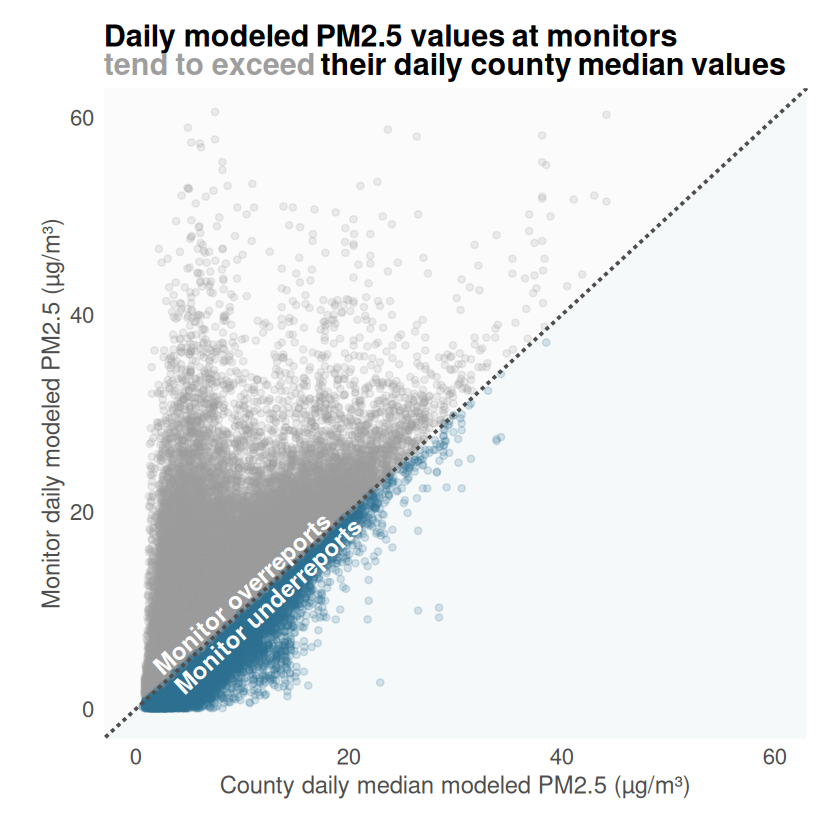

In [25]:
#Purpose of Cell Block: Assess the overall distrubution for every monitor and every day based on the relationship between a modeled PM2.5 value at the monitor and the modeled PM2.5 median value at the monitors' county. 

setwd("/home/user/capstone/A_data")

DF_altpm25_w_county_median_processed <- read_csv(
  "D_processed_data/final_output/monitor_value_vs_county_value.csv"
) #starting data pull from export above so I don't have to rerun those steps as I refine my imagery

monitorday_vs_countyday_vis <- DF_altpm25_w_county_median_processed %>%
  filter(
    !is.na(Alt_PM25), #remove all NA from Alt_PM25 column
    !is.na(county_daily_median) #remove all NA from county_daily_median
  ) %>%  
  ggplot(
    aes(
      x = county_daily_median, #x-axis is the median county value
      y = Alt_PM25, #y-axis is the value at he monitor itself (this was selected so overreports would be above the dividing line and underreports uner)
      color = county_daily_median < Alt_PM25 #adding color when the monitor's pm2.5 value is cgreater than the county median -> "TRUE" = overreport  = "#9E9E9E" and "FALSE" = underreport = "#2E6F95"
    )
  ) +  
  annotate(  #adding in very transparent poligon for false area (gray = overreports)
    "polygon",
    x = c(-Inf, Inf, -Inf),
    y = c(-Inf, Inf, Inf),
    fill = "#9E9E9E",
    alpha = 0.04
  ) +  
  annotate( #adding in very transparent poligon for true area (blue = underreports)
    "polygon",
    x = c(-Inf, Inf, Inf),
    y = c(-Inf, -Inf, Inf),
    fill = "#2E6F95",
    alpha = 0.04
  ) +
  
  geom_point( #setting the graph as points that are transparent to increase the likelihood we'll see the bulk of the data (there are so many points that they cover each other)
    alpha = 0.18,
    size = 1.4
  ) +  
  geom_abline( #adding in the divding line - points close to this line reflect monitr well represents its county on the given day
    slope = 1,
    intercept = 0,
    linetype = "dashed",
    color = "#4D4D4D",
    linewidth = 0.8
  ) +

annotate( #label above line showing overreport area
  "text",
  x = 2,
  y = 4,   
  label = "Monitor overreports",
  angle = 42,
  color = "white",
  size = 5,
  fontface = "bold",
  hjust = 0
) +

annotate( #label below line showing underreport area
  "text",
  x = 4,
  y = 2,   # x - 5
  label = "Monitor underreports",
  angle = 43,
  color = "white",
  size = 5,
  fontface = "bold",
  hjust = 0
)+
  scale_color_manual( #establishing color scale for over and underreports. see logic above for how it's applied
    values = c(
      "TRUE"  = "#9E9E9E", #gray
      "FALSE" = "#2E6F95" #blue
    )
  ) +
labs( #adding in lables
  title = paste0( #somewhat complex title, adding in gray color on speific words "tend to exceed" to align with chart
    "<span style='font-weight:700;'>",
    "Daily modeled PM2.5 values at monitors<br>",
    "<span style='color:#9E9E9E;'>tend to exceed</span> ",
    "their daily county median values",
    "</span>"
  ),
  x = "County daily median modeled PM2.5 (µg/m³)",
  y = "Monitor daily modeled PM2.5 (µg/m³)"
) +

  
  coord_cartesian( #widening the chart area
    xlim = c(0, 60),
    ylim = c(0, 60)
  ) +
  
  theme_smg() + #applying common theme establed in a previous cell block (cleaning up any inconsistencies i introduce in this cell block)
  
  theme(
    legend.position = "none"
  )

monitorday_vs_countyday_vis


ggsave(
  "E_outputs/figures/monitor-day_vs_county_day_vis.png",
  monitorday_vs_countyday_vis,
  width = 9,
  height = 7,
  dpi = 300
)

#Conclusion: When viewed holistically, the plot of every single monitors daily data versus their county median daily data shows that monitor underreports (when a monitors value is lower than the county median) tend to closely align with each other. On the other hand, monitor overreports (when a monitor reports higher data than its county) area widely dispersed. Overall this demonstrates that the monitoring network generally well-represents or overreports its county data. 

AQS_Site_ID,COUNTYNS,date,Alt_PM25,county_daily_median,alt_median_difference,alt_percent_difference
<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>
010030010,00161527,2019-01-01,7.2,6.405162,-0.79483768,-12.409329
010270001,00161539,2019-01-01,6.0,5.789027,-0.21097260,-3.644353
010331002,00161542,2019-01-01,5.0,5.073783,0.07378324,1.454205
010491003,00161550,2019-01-01,6.2,6.163019,-0.03698120,-0.600050
010550010,00161553,2019-01-01,7.9,6.394607,-1.50539262,-23.541595
010690003,00161560,2019-01-01,10.4,10.603614,0.20361428,1.920235


monitor_overreports,n,percent
<lgl>,<int>,<dbl>
FALSE,145188,0.4151194
TRUE,204562,0.5848806


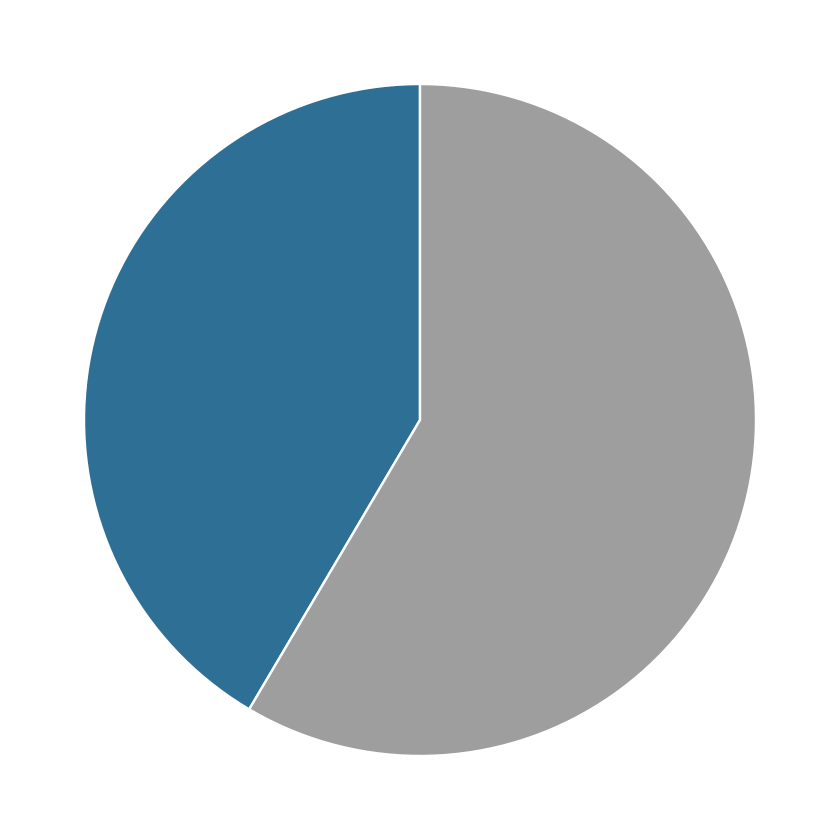

In [26]:
#Purpose of Cell: Create pie chart for monitor bias proportions. This will be combined with the above chart for a broader understanding

monitor_bias_summary <- DF_altpm25_w_county_median_processed %>%
  filter(
    !is.na(Alt_PM25), #remove all NA from Alt_PM25 column
    !is.na(county_daily_median) #remove all NA from county_daily_median
  ) %>%
  mutate(
    monitor_overreports = county_daily_median < Alt_PM25 #adding count when the monitor's pm2.5 value is greater than the county median -> "TRUE" = overreport  = "#9E9E9E" and "FALSE" = underreport = "#2E6F95"
  ) %>%
  count(monitor_overreports) %>% #couning up the overreports (counting the number of overeports = t and = f
  mutate(
    percent = n / sum(n) #adding new column the percent (n was craeted by the count of overreports)
  )

head(DF_altpm25_w_county_median_processed) #quickly showing the data i was working with 
monitor_bias_summary #show the output of the work above



monitor_bias_pie <- monitor_bias_summary %>% #creating pie chart with t and f on whether it's a monitor overreport
  ggplot(
    aes(
      x = "",
      y = percent,
      fill = monitor_overreports 
    )
  ) +
  
  geom_col( #creating cololumns of t and f
    width = 1, #establishing border as white
    color = "white"
  ) +
  
  coord_polar("y") + #converting to pie chart
  
  scale_fill_manual( #setting color conditions
    values = c(
      "TRUE"  = "#9E9E9E",   #overreports (gray)
      "FALSE" = "#2E6F95"    #underreports (blue)
    )
  ) +
  
  theme_void() + #removing unecessary info (I'll be combining this with the chart above)
  
  theme(
    legend.position = "none"
  )

monitor_bias_pie

#Conclusion: Dispersion from the center 1:1 correlation line from above aside, 58 percent of every single monitors' daily data versus their county median daily data are overreports. The remaining 41.5 percent values are underreports (when a monitors value is lower than the county median). In addition to the dispersion findings identified in the previous chart, this pie chart shows that monitor values overreport more often than underreport, demonstrating that the monitoring network is generally well-positioned to detect PM2.5 relative to other locations in the county. 

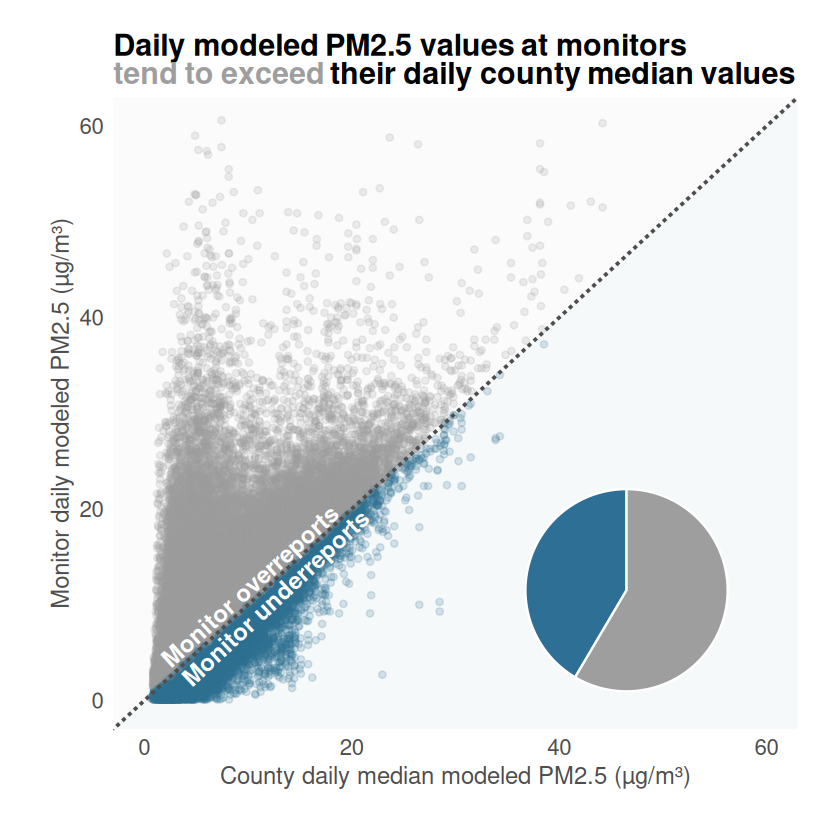

In [27]:
#Purpose of Cell: Combine the pie chart wiht the scatter plot for a better understanding of the bigger picture when discussing the universe of all data points
combined_monitor_plot <- monitorday_vs_countyday_vis + #start with the scatter plot
  inset_element(
    monitor_bias_pie, #insert the pie charton the bottom right hand corner
    left   = 0.55,
    bottom = 0.02,
    right  = 0.95,
    top    = 0.42
  )

combined_monitor_plot

ggsave(
  "E_outputs/figures/monitor-day_vs_county_day_with_pie.png",
  combined_monitor_plot,
  width = 9,
  height = 7,
  dpi = 300
)

#Conclusion: No additional conclusions. See above findings discussion.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


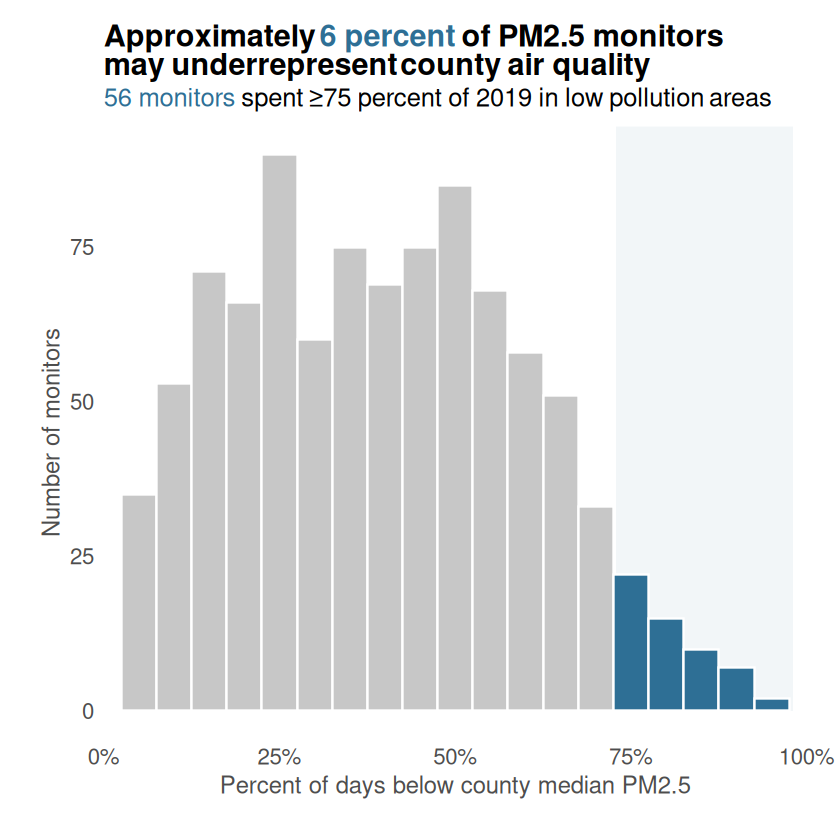

In [28]:
#Purpose of Cell: Acknowledging that even one monitor that is poorly positioned relative to county pollution is worth investigating further, develop another chart that arranges monitor underreporting time percentages into histogram bars (i.e., show the distribution of monitors to identify those that spend the majority of the year in relatively low pollution areas)

monitor_below_median <- DF_altpm25_w_county_median_processed %>%   
  group_by(AQS_Site_ID, COUNTYNS) %>% #summarizing by each monitor and each county
  summarise(
    pct_below_median = mean(Alt_PM25 < county_daily_median, na.rm = TRUE), #drop NA and collect the average time a monitor was in a relatively low pollution area. this creates a count of t and f and then identifies the mean of the two, which is pct (i.e., t = 1 and f = 0 )
    .groups = "drop"
  ) %>%
  filter(!is.na(pct_below_median)) %>% #drop NA in newcolumn
  arrange(pct_below_median) #arrange the values from lowest percent of days in low pollution areas to highest

n_total_monitors <- nrow(monitor_below_median) #calculate the number rows in dataset
n_monitors_ge_75 <- sum(monitor_below_median$pct_below_median >= 0.75) #calculate the number of times a monitor was in low pollutin areas at least 75 percent of the year
percent_monitors_ge_75 <- round(100 * n_monitors_ge_75 / n_total_monitors, 0) #percent of above

binwidth <- 0.05 #updating binwidth so the monitor overreports and underreports won't fall halfway in a bin
breaks <- seq(0, 1, by = binwidth)

hist_df <- monitor_below_median %>% #using calculations above, create a historgram
  mutate(
    bin = cut(pct_below_median, breaks = breaks, include.lowest = TRUE, right = FALSE) #define bin edges to make sure overeports and underreports won't fall halfway (see above; also make sure 0s are shown if needed)
  ) %>%
  count(bin, name = "n") %>% #count in each bin
  mutate(
    bin_left = as.numeric(sub("\\[(.*),.*", "\\1", as.character(bin))), #plot from left 
    highlight = bin_left >= 0.75 #flag the 75% area for targeting closer look
  )

monitor_distribution <- ggplot(hist_df, aes(x = bin_left, y = n, fill = highlight)) + #plotting above histogram using ggplot and the common themes i set above
  annotate("rect",
           xmin = 0.73, xmax = .98,
           ymin = 0, ymax = Inf,
           fill = "#2E6F95", alpha = 0.06) + #set transparent rectangle that is blue, targeting the area where monitors underreported 75% of the year
  geom_col(width = binwidth, color = "white") + #setting white borders to align with earlier charts
  scale_fill_manual(values = c("FALSE" = "#C7C7C7", "TRUE" = "#2E6F95")) + #filling color = blue for underreport and gray for ovrreport
  scale_x_continuous(labels = scales::percent_format(), limits = c(0, 1), breaks = seq(0, 1, 0.25), expand = c(0, 0)) + #adding in the percent scale
  labs(
    title = paste0( #somewhat complex title, adding in blue color on specific words percent to align with chart
      "<span style='font-weight:700;'>",
      "Approximately <span style='color:#2E6F95;'>",
      percent_monitors_ge_75, #note that span begin and end controls begin and end of color
      " percent</span> of PM2.5 monitors<br>", #note that break is needed instead of new line here
      "may underrepresent county air quality",
      "</span>"
    ),
    subtitle = paste0(
      "<span style='color:#2E6F95; font-weight:600;'>", #similar to title, coloring specific words to draw attention to them
      n_monitors_ge_75,
      " monitors</span> spent ≥75 percent of 2019 in low pollution areas"
    ),
    x = "Percent of days below county median PM2.5",
    y = "Number of monitors"
  ) +
  theme_smg() + #applying common theme establed in a previous cell block (cleaning up any inconsistencies I introduce in this cell block)
  theme(legend.position = "none")

monitor_distribution

ggsave("E_outputs/figures/monitor_distribution_75_threshold.png",
       monitor_distribution, width = 10, height = 7, dpi = 300)

write_csv(monitor_below_median, "D_processed_data/final_output/monitor_below_median.csv")

#Conclusion: 6 percent of all monitors operating in 2019 were located in relatively low pollution areas at least 75 percent of the year. That percentage translates to 56 monitors. It may be worthwhile to investigate these monitors further to understand why they so often are located in areas below the county median pollution

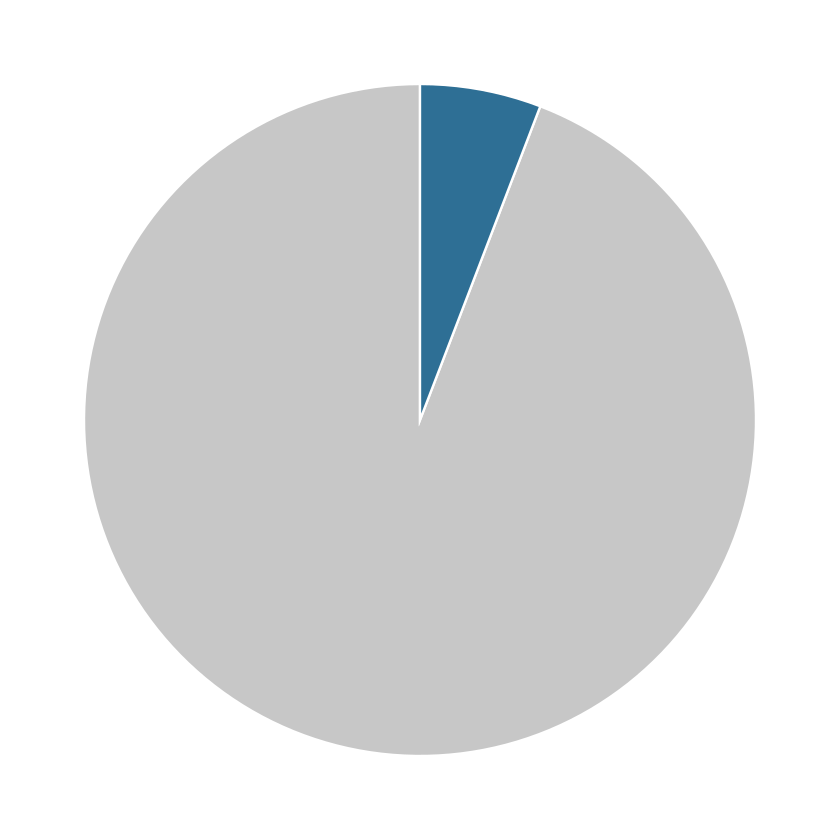

In [29]:
#Purpose of Cell: Create pie chart for monitor bias proportions. This will be combined with the above chart for a broader understanding

pie_df <- monitor_below_median %>%
  mutate(category = ifelse(pct_below_median >= 0.75, #create t/f based on whether the monitor's daily value was below county 75 percent of the year
                           "≥ 75%",
                           "< 75%")) %>%
  count(category) %>% #count the t/f
  mutate(percent = n / sum(n)) #create a new column with the count converted in to a percentage for the pie chart

pie_chart <- ggplot(pie_df, aes(x = "", y = percent, fill = category)) + #crate pie chart wiht the fill based on "category" se above
  geom_col(width = 1, color = "white") + #column
  coord_polar(theta = "y") + #column to pie
  
  scale_fill_manual(
    values = c("≥ 75%" = "#2E6F95", #blue for overreports
               "< 75%" = "#C7C7C7") #slightly darker gray to make easier to see for underreports
  ) +
  
  theme_void() + #remove extranious info because this will be combined with above chart
  
  theme( #again remove not needed
    legend.position = "none",
    plot.background = element_rect(fill = NA, color = NA),
    panel.background = element_rect(fill = NA, color = NA)
  )

pie_chart

ggsave(
  "E_outputs/figures/monitor_share_75_pie_inset.png",
  pie_chart,
  width = 4,
  height = 4,
  dpi = 300,
  bg = "transparent"
)

#Conclusion: The percentages were already provided in the previous chart but this pie chart reinforces them visually. No new conclusions.

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


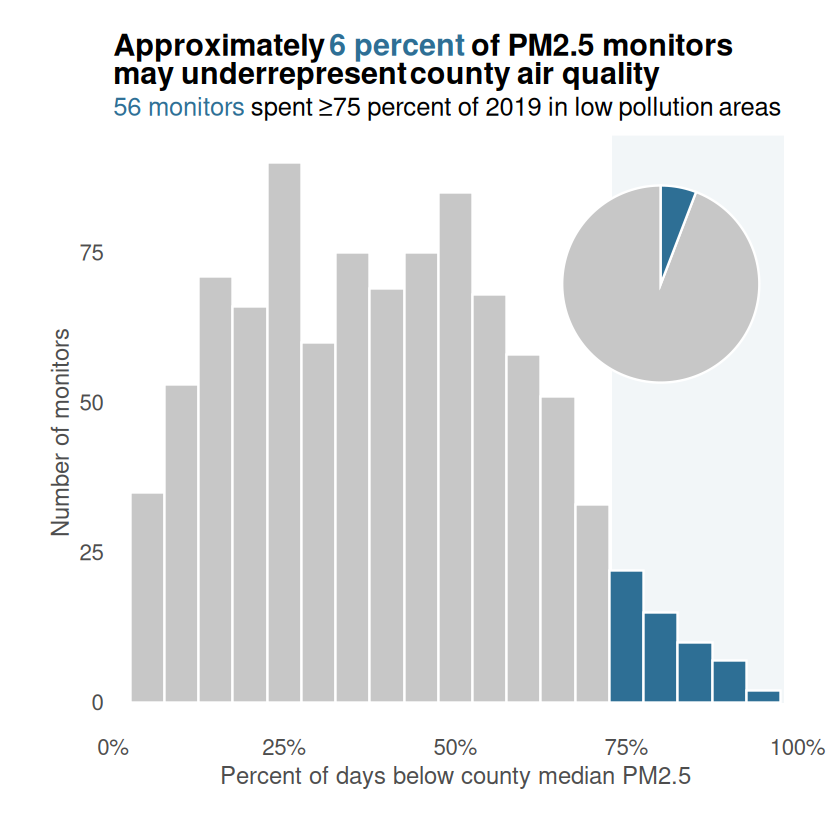

In [30]:
#Purpose of Cell: Combine the pie chart wiht the scatter plot for a better understanding of the bigger picture when discussing the universe of all data points

combined_plot <- monitor_distribution + #start with historgram
  inset_element( #insert pie chart and place it in the upper right
    pie_chart,
    left   = 0.62,   
    bottom = 0.52,   
    right  = 0.98,   
    top    = 0.98    
  )

combined_plot

ggsave(
  "E_outputs/figures/monitor_distribution_with_pie.png",
  combined_plot,
  width = 10,
  height = 7,
  dpi = 300
)
#Conclusions: No new conclusions. See the original discussion for the historgram. 

In [33]:
#Purpose of Cell: To identify the top states where underreporting may bias the states moniotring data, combine state and county metadata to create a unique identifier to attach to the monitor underreporting dataset generated earlier for summary statistics by state

setwd("/home/user/capstone/A_data")

states <- st_read( #load in census data for state boundaries
  "C_raw_data/census/state_boundaries", #ADD THIS TO SOURCE
  quiet = TRUE
) %>%
  mutate(
    FIPS_Fix = STATEFP #update FIPS to allow me to align it to the county data 
  ) %>%
  select(FIPS_Fix, STUSPS, geometry) #drop all metadata except wht's necessary

contiguous_counties <- st_read( #load in census data for county boundaries (using the contiguous counties datasetI created in earlier notebook) #ADD THIS TO SOURCE
  "D_processed_data/intermediate_scratch/contiguous_counties.gpkg",
  quiet = TRUE
) %>%
  mutate(
    FIPS_Fix = substr(GEOID, 1, 2)   #state FIPS from county GEOID
  ) %>%
  select(COUNTYNS, FIPS_Fix) #keeping only the fips and county ns for later combination with state


monitor_below_median_w_state <- monitor_below_median %>% #attach dataset created above to the congiuos geographies counties dataset
  left_join(contiguous_counties, by = "COUNTYNS")

state_below_median <- monitor_below_median_w_state %>% #calculate the average percent of time monitors in each state were in low pollution areas and the total number  of monitors in each state
  group_by(FIPS_Fix) %>% 
  summarise(
    state_mean_pct_below = mean(pct_below_median, na.rm = TRUE),
    n_monitors = n(),
    .groups = "drop"
  )

states_mapped <- states %>% #align with state dataset
  left_join(state_below_median, by = "FIPS_Fix")

states_mapped <- states_mapped %>%
  filter(!is.na(state_mean_pct_below))

st_write(
  states_mapped,
  "D_processed_data/final_output/states_below_median_v02.gpkg",
  delete_dsn = TRUE
)


Deleting source `D_processed_data/final_output/states_below_median_v02.gpkg' using driver `GPKG'
Writing layer `states_below_median_v02' to data source 
  `D_processed_data/final_output/states_below_median_v02.gpkg' using driver `GPKG'
Writing 49 features with 4 fields and geometry type Multi Polygon.


STATE,pct_below_percent,deviation_percent
<chr>,<dbl>,<dbl>
MD,65.0,15.0
ND,57.8,7.8
NV,53.7,3.7
MO,53.6,3.6


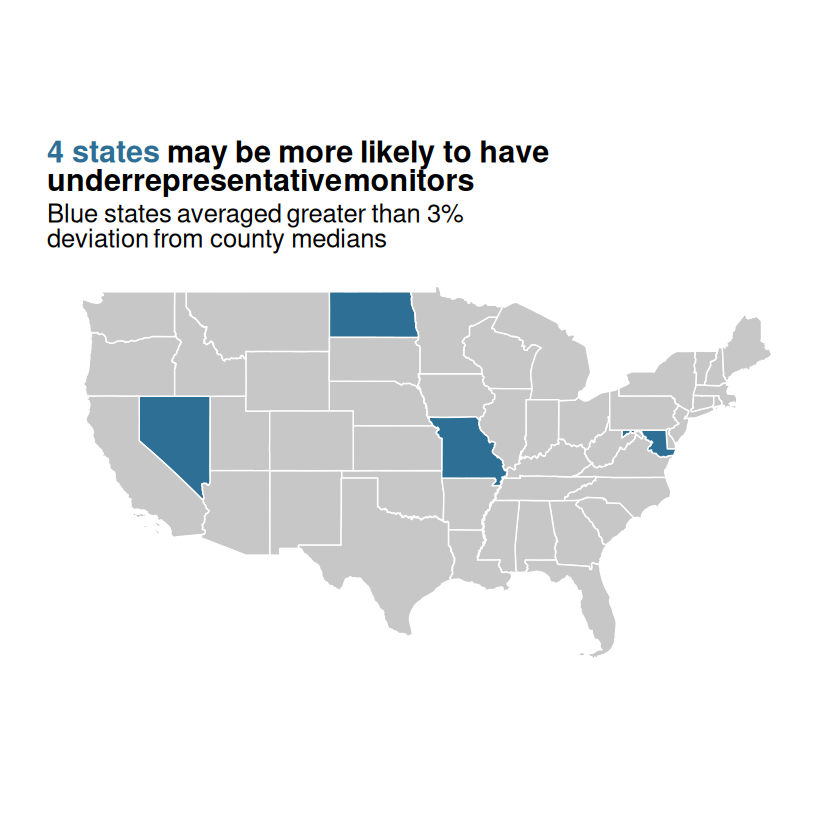

In [34]:
#Purpose of Cell: Identify the top states where underreporting may bias the states moniotring data (note this doesn't necessarily mean the 56 monitors identified in the histogram above appear in the identified states. Addtional work is needed to identify those. Rather, this is showing where bias may overall influence the states air quality data)

my_data3 <- st_read( #using generic dataframe name from homework assignment
  "D_processed_data/final_output/states_below_median_v02.gpkg", #pulling in processed dataset
  quiet = TRUE
) 

my_data3 <- my_data3 %>% #again, generic name due to homework assignment. 
  mutate(
    deviation = state_mean_pct_below - 0.5, #calculating deviation from median
    highlight = deviation > 0.03   # > 3 percentage points deviation means the states will be highlighted for additional nvestigation
  )


n_states_highlight <- sum(my_data3$highlight, na.rm = TRUE) #Count qualifying states

viz3 <- ggplot(my_data3) + #generic name due to homework assignment. however, this is the ggplot on a map using SF
  
  geom_sf(
    aes(fill = highlight),
    color = "white", #white borders between states to align with earlier visuals for a professional look
    linewidth = 0.3
  ) +
  
  scale_fill_manual( #setting scale. originally went with continuous scale but the overreporting states confused the messaging. new scale simply shows the states that may be worth additional investigation.
    values = c(
      "FALSE" = "#C7C7C7",  #soft gray
      "TRUE"  = "#2E6F95"   #blue
    ),
    guide = "none"
  ) +
  
  labs(
    title = paste0(
      "<span style='font-weight:700;'>",
      "<span style='color:#2E6F95;'>", 
      n_states_highlight,
      " states</span> may be more likely to have<br> underrepresentative monitors</span>" #adding in a somewhat complext title that will highlight the number of states
    ),
    subtitle = "Blue states averaged greater than 3%<br> deviation from county medians" #note need to use break to create new line
  ) +
  
  theme_smg() + #adding in common theme
  
  theme( #getting rid of unecessary elements
    axis.title = element_blank(),
    axis.text = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank()
  )

viz3

ggsave(
  "E_outputs/figures/monitor_geospatial_distribution.png",
  viz3,
  width = 10,
  height = 6,
  dpi = 300
)


state_table <- my_data3 %>% #for exact percentages of the highlighted states, creating a table
  st_drop_geometry() %>% #dont need geometry so speeding things up
  mutate(
    deviation_percent = round(100 * (state_mean_pct_below - 0.5), 1), #calculate deviation percent from median
    pct_below_percent = round(100 * state_mean_pct_below, 1) #calculate total percent below
  ) %>%
  arrange(desc(deviation_percent)) %>% #arranging by highest deviation percent to loweest
  select( #selecting only the columns that matter
    STATE = STUSPS,      
    pct_below_percent,
    deviation_percent
  ) %>%
  as_tibble()

head(state_table,4) #showing only the states that are highlighted in the map

#Conclusion: Geospatial analysis indicates that the histogram-identified monitors may be in Maryland, North Dakota, Nevada, and Missouri (note not necessarily but these are the areas where I've identified the greates possible underreporting bias). The monitors' locations in these states may result in underestimates of representative air quality by approximately 15.0, 7.8, 3.7, and 3.6 percent, respectively. 